# Discount Uplift Model — T-Learner vs X-Learner (Observational-Only)

Estimates the individual causal effect (CATE) of offering a customer a discount
(5, 10, 15, 20 or 25% for 3, 6, 9 or 12 months, against a single no-discount control arm) on retention, relative to no discount. Downstream of `churn_model.ipynb`,
`sentiment_model.ipynb`, and `late_fusion.ipynb` — consumes `churn_proba`,
`sentiment_score`, and `fused_proba` as features. Output: a recommended discount
tier per customer.

**Data**: `Datasets/uplift_observational.csv` only — one row per customer, generated by `Datasets/generate_uplift_observational.py`, the discount
tier actually assigned (confounded, not randomized), and the actual outcome. No
ground-truth potential outcomes or true CATE columns exist anywhere in this data,
by design: a real company never has that information either. Every validation
technique below has to work without ever seeing the "answer" for a counterfactual
discount a customer didn't receive — the same blind conditions a real deployment
would face.

**What changes vs. a ground-truth-benchmarked version**: PEHE (root-mean-squared
error against a true effect) is impossible to compute without ground truth. In its
place: a **Qini curve** for ranking quality (does the model correctly sort
high-uplift customers to the top?), built from a **doubly-robust pseudo-outcome**
so it stays reasonably low-variance despite the data being confounded, and a
**doubly-robust off-policy value estimate** (with a confidence interval) for
"would this model's recommendations have actually helped." Both techniques come
from the off-policy evaluation literature — the standard toolkit for judging a
decision policy against logged, non-randomized data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
import joblib, os, json

SEED = 42
# The treatment is a (percentage, duration) pair now, not a bare percentage, so an
# "arm" is a label like "10_6" - 10% for 6 months. "0_0" is the control. Everything
# downstream keys on these labels, so the T-learner, X-learner, propensity model,
# Qini and policy-value machinery are unchanged by the added dimension.
CONTROL = '0_0'
DISCOUNT_PCTS = [5, 10, 15, 20, 25]
DISCOUNT_MONTHS = [3, 6, 9, 12]
TREATMENT_TIERS = [f'{p}_{m}' for p in DISCOUNT_PCTS for m in DISCOUNT_MONTHS]
DISCOUNT_TIERS = [CONTROL] + TREATMENT_TIERS

# One control arm: 0% with no duration. The percentages above exclude 0, so no tier can be
# "0% for N months" - four copies of the control would split the group every treated arm
# is measured against. Checked from the lists themselves, never against a literal count.
assert 0 not in DISCOUNT_PCTS
assert len(DISCOUNT_TIERS) == 1 + len(DISCOUNT_PCTS) * len(DISCOUNT_MONTHS)
assert not [t for t in TREATMENT_TIERS if t.startswith('0_')]

## 1. Load Data

In [2]:
# The synthetic data is always read from the generator's current output. Real renewal outcomes come
# from the file Datasets/retrain_with_outcomes.py writes, and only its REAL rows are taken: its
# synthetic half is a copy made whenever that script last ran, so reading the whole file would quietly
# train on an older grid if the generator had been re-run since. Until an export has run, the file
# does not exist and training uses the synthetic data alone.
df = pd.read_csv('Datasets/uplift_observational.csv')
SYNTH_COLUMNS = list(df.columns)
df['is_real'] = 0
MERGED = 'Datasets/uplift_observational_with_real.csv'
if os.path.exists(MERGED):
    merged = pd.read_csv(MERGED)
    df = pd.concat([df, merged[merged['is_real'] == 1]], ignore_index=True)
is_real = df['is_real'] == 1

# One label per treatment arm. The treatment is a (percentage, duration) pair, and a T-learner
# fits one model per arm, so rows-per-arm is the binding constraint on this design rather than
# rows overall - which is why the dataset was resized to suit the grid. A missing percentage or
# duration labels as -1, which is on no arm, rather than as a float label like "10.0_6.0".
def arm_part(col):
    return pd.to_numeric(df[col], errors='coerce').fillna(-1).astype(int).astype(str)
df['arm'] = arm_part('discount_pct') + '_' + arm_part('discount_months')

# A row off the grid has no arm model to belong to, and a one-row arm makes the stratified split
# below raise. A SYNTHETIC row off the grid means the generator is wrong, so stop. A REAL one is an
# offer made outside the grid, or a 0% offer stored with a duration - a second copy of the control
# arm - so drop it and say which.
off_grid = ~df['arm'].isin(DISCOUNT_TIERS)
if (off_grid & ~is_real).any():
    raise ValueError(f'synthetic rows off the arm grid: {sorted(df.loc[off_grid & ~is_real, "arm"].unique())}')
if off_grid.any():
    print(f'dropping {int(off_grid.sum())} real row(s) outside the {len(DISCOUNT_TIERS)} arms: '
          f'{sorted(df.loc[off_grid, "arm"].unique())}')
    df, is_real = df[~off_grid].reset_index(drop=True), is_real[~off_grid].reset_index(drop=True)
print(f'real renewal rows: {int(is_real.sum())} of {len(df):,}')

print(df.shape)
print(df.dtypes)
# Over the columns every row has. Real rows carry extra columns that synthetic rows leave empty,
# and counting those would report hundreds of thousands of meaningless gaps.
print('\nMissing values:', df[SYNTH_COLUMNS].isnull().sum().sum())
print('\nrows per arm:')
print(df['arm'].value_counts().sort_index())
print('\nRetained rate:', df['Retained'].mean().round(4))

real renewal rows: 0 of 340,000
(340000, 17)
customer_id                object
Account_Age_Days            int64
Daily_Usage_Mins            int64
Support_Tickets_90Days      int64
API_Utilization_Rate      float64
churn_proba               float64
sentiment_score           float64
fused_proba               float64
Login_Frequency            object
Plan_Tier                  object
Dominant_SHAP_Driver       object
risk_band                  object
discount_pct                int64
discount_months             int64
Retained                    int64
is_real                     int64
arm                        object
dtype: object

Missing values: 0

rows per arm:
arm
0_0      110318
10_12     10582
10_3       6726
10_6       8624
10_9       9615
15_12     13687
15_3       8591
15_6      11283
15_9      12388
20_12     16777
20_3      10067
20_6      13649
20_9      15259
25_12     19428
25_3      11845
25_6      16479
25_9      17786
5_12       7894
5_3        5196
5_6        6546
5_9  

## 2. Confounding Check

`discount_pct` was not randomly assigned — bigger discounts were targeted at
riskier customers. A raw group-mean comparison of retention by discount tier
would be comparing different populations, not the causal effect of the discount
itself.

Mean churn_proba by discount_pct (targeting pattern):
discount_pct
0     0.4233
5     0.4852
10    0.5332
15    0.5655
20    0.5862
25    0.5970
Name: churn_proba, dtype: float64

discount_pct distribution by risk_band:
discount_pct     0      5      10     15     20     25
risk_band                                             
High          0.179  0.065  0.111  0.165  0.216  0.264
Low           0.464  0.090  0.097  0.107  0.115  0.127
Medium        0.328  0.081  0.105  0.135  0.162  0.189


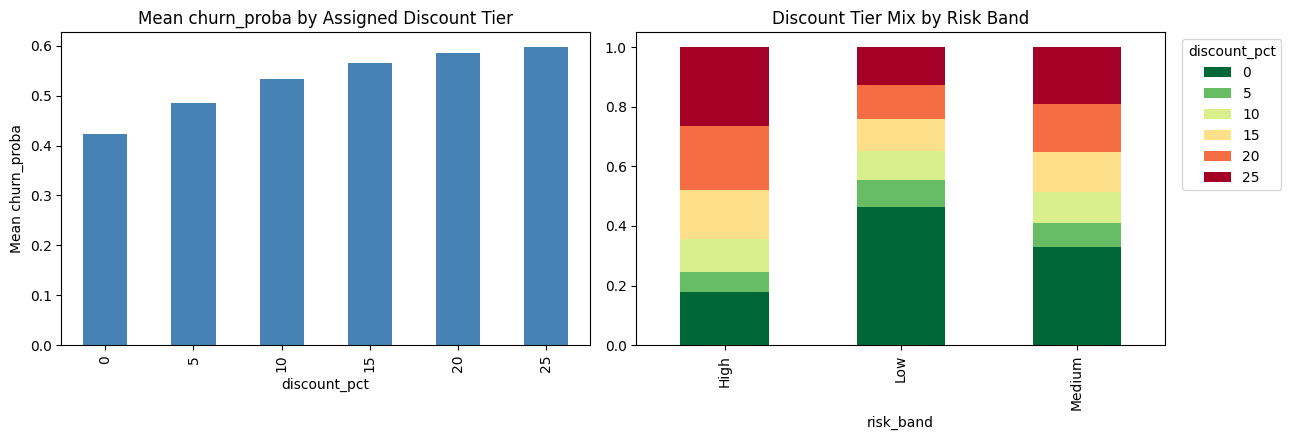

In [3]:
print('Mean churn_proba by discount_pct (targeting pattern):')
print(df.groupby('discount_pct')['churn_proba'].mean().round(4))

print('\ndiscount_pct distribution by risk_band:')
print(pd.crosstab(df['risk_band'], df['discount_pct'], normalize='index').round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df.groupby('discount_pct')['churn_proba'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Mean churn_proba by Assigned Discount Tier')
axes[0].set_ylabel('Mean churn_proba')
pd.crosstab(df['risk_band'], df['discount_pct'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title('Discount Tier Mix by Risk Band')
axes[1].legend(title='discount_pct', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Train / Validation / Test Split

70/15/15, stratified by `discount_pct`.

In [4]:
# MRR and Days_To_Renewal were dropped from this model. Under standardised tier
# pricing MRR is a one-to-one relabelling of Plan_Tier, so it carries no information
# the model does not already have; Days_To_Renewal is a calendar position rather than
# an account attribute, and measurably carried no signal (sweeping it across a full
# year moved baseline retention 0.2pp and changed no recommendation).
#
# Dominant_SHAP_Driver is added. It was a column in the previous dataset but never a
# feature — and it is what decides the SHAPE of the best offer, so without it the
# model cannot rank durations at all. Trained without it, recovery of the true best
# duration came out BELOW random.
NUM_FEATURES = ['Account_Age_Days', 'Daily_Usage_Mins', 'Support_Tickets_90Days',
                'API_Utilization_Rate', 'churn_proba', 'sentiment_score', 'fused_proba']
CAT_FEATURES = ['Login_Frequency', 'Plan_Tier', 'risk_band', 'Dominant_SHAP_Driver']
X_COLS = NUM_FEATURES + CAT_FEATURES

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['arm'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['arm'])

print('train:', train_df.shape, ' val:', val_df.shape, ' test:', test_df.shape)

train: (238000, 17)  val: (51000, 17)  test: (51000, 17)


## 4. Preprocessing — Fit Once, Reuse Everywhere

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
])
preprocessor.fit(train_df[X_COLS])

X_train = preprocessor.transform(train_df[X_COLS])
X_val = preprocessor.transform(val_df[X_COLS])
X_test = preprocessor.transform(test_df[X_COLS])

d_train = train_df['arm'].to_numpy()
y_train = train_df['Retained'].to_numpy()
driver_val = val_df['Dominant_SHAP_Driver'].to_numpy()
driver_test = test_df['Dominant_SHAP_Driver'].to_numpy()

print('Transformed feature matrix:', X_train.shape[1], 'columns from', len(X_COLS), 'raw features')

Transformed feature matrix: 18 columns from 11 raw features


## 5. Confounded-Naive Baseline

The one baseline that's still computable without ground truth — and it's exactly
the comparison a company might make by mistake if it didn't correct for
confounding.

In [6]:
naive_diff = {}
for d in TREATMENT_TIERS:
    m_t = y_train[d_train == d].mean()
    m_c = y_train[d_train == CONTROL].mean()
    naive_diff[d] = round(float(m_t - m_c), 4)
print('Confounded-naive (diff-in-means, train):', naive_diff)
print()
print('Note: there is no "oracle-constant ATE" reference this time — computing the true')
print('average effect requires the ground-truth potential outcomes, which this dataset')
print('deliberately does not have. A real company could not compute this ceiling either.')

Confounded-naive (diff-in-means, train): {'5_3': 0.0865, '5_6': 0.079, '5_9': 0.0608, '5_12': 0.0573, '10_3': 0.1125, '10_6': 0.1037, '10_9': 0.0799, '10_12': 0.0606, '15_3': 0.1014, '15_6': 0.0749, '15_9': 0.0385, '15_12': -0.0396, '20_3': 0.0862, '20_6': 0.0268, '20_9': -0.0796, '20_12': -0.1712, '25_3': 0.0735, '25_6': -0.0586, '25_9': -0.1845, '25_12': -0.2473}

Note: there is no "oracle-constant ATE" reference this time — computing the true
average effect requires the ground-truth potential outcomes, which this dataset
deliberately does not have. A real company could not compute this ceiling either.


## 6. Multinomial Propensity Model

Propensity overlap (val) - min / mean / max per arm:
  arm 0_0: min=0.1261  mean=0.3240  max=0.5534
  arm 10_12: min=0.0220  mean=0.0312  max=0.0403
  arm 10_3: min=0.0135  mean=0.0198  max=0.0260
  arm 10_6: min=0.0208  mean=0.0253  max=0.0295
  arm 10_9: min=0.0215  mean=0.0283  max=0.0368
  arm 15_12: min=0.0188  mean=0.0403  max=0.0676
  arm 15_3: min=0.0201  mean=0.0252  max=0.0311
  arm 15_6: min=0.0184  mean=0.0332  max=0.0450
  arm 15_9: min=0.0200  mean=0.0365  max=0.0560
  arm 20_12: min=0.0205  mean=0.0494  max=0.0864
  arm 20_3: min=0.0192  mean=0.0296  max=0.0397
  arm 20_6: min=0.0210  mean=0.0402  max=0.0616
  arm 20_9: min=0.0201  mean=0.0449  max=0.0817
  arm 25_12: min=0.0232  mean=0.0572  max=0.0995
  arm 25_3: min=0.0209  mean=0.0349  max=0.0462
  arm 25_6: min=0.0225  mean=0.0485  max=0.0786
  arm 25_9: min=0.0227  mean=0.0524  max=0.0898
  arm 5_12: min=0.0155  mean=0.0232  max=0.0289
  arm 5_3: min=0.0073  mean=0.0152  max=0.0247
  arm 5_6: min=0.0127  mean=0.019

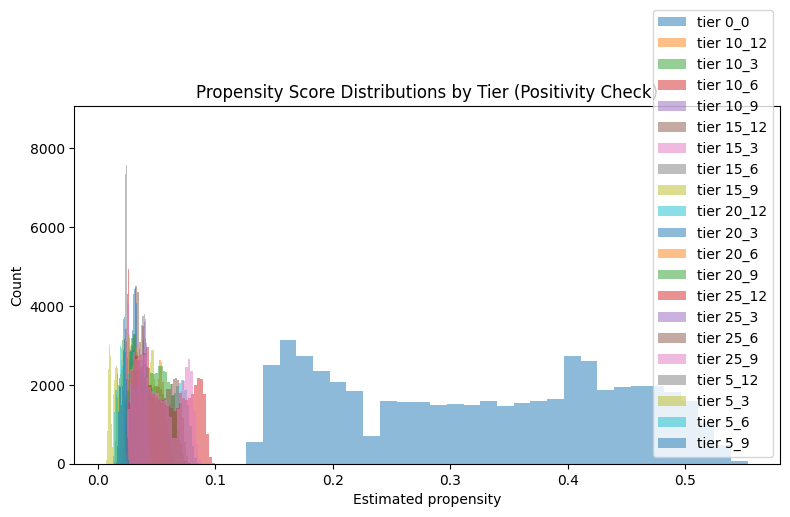

In [7]:
multi_propensity = LogisticRegression(max_iter=2000)
multi_propensity.fit(X_train, d_train)

prop_val = multi_propensity.predict_proba(X_val)
print('Propensity overlap (val) - min / mean / max per arm:')
for i, d in enumerate(multi_propensity.classes_):
    col = prop_val[:, i]
    print(f'  arm {d}: min={col.min():.4f}  mean={col.mean():.4f}  max={col.max():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
for i, d in enumerate(multi_propensity.classes_):
    ax.hist(prop_val[:, i], bins=30, alpha=0.5, label=f'tier {d}')
ax.set_xlabel('Estimated propensity'); ax.set_ylabel('Count')
ax.set_title('Propensity Score Distributions by Tier (Positivity Check)')
ax.legend()
plt.tight_layout()
plt.show()

No tier's propensity distribution collapses toward 0 across the board — every
customer had a realistic chance of landing in any tier given their covariates.
Positivity holds well enough to trust IPW/doubly-robust corrections downstream.

## 7. T-Learner and X-Learner

In [8]:
def make_base_learner(max_depth):
    return lambda: RandomForestRegressor(n_estimators=300, max_depth=max_depth,
                                          min_samples_leaf=15, random_state=SEED, n_jobs=-1)


def fit_t_pooled(base_factory):
    models = {}
    for d in DISCOUNT_TIERS:
        mask = d_train == d
        reg = base_factory(); reg.fit(X_train[mask], y_train[mask]); models[d] = reg
    return models


def t_cate(models, X, d):
    return models[d].predict(X) - models[CONTROL].predict(X)


def fit_x_pooled(base_factory):
    mu = {}
    for d in DISCOUNT_TIERS:
        mask = d_train == d
        reg = base_factory(); reg.fit(X_train[mask], y_train[mask]); mu[d] = reg

    propensity, tau1, tau0 = {}, {}, {}
    for d in TREATMENT_TIERS:
        mask_c = d_train == CONTROL
        mask_t = d_train == d
        mask_either = mask_c | mask_t

        prop_model = LogisticRegression(max_iter=1000)
        prop_model.fit(X_train[mask_either], (d_train[mask_either] == d).astype(int))
        propensity[d] = prop_model

        D1 = y_train[mask_t] - mu[CONTROL].predict(X_train[mask_t])
        D0 = mu[d].predict(X_train[mask_c]) - y_train[mask_c]

        tau1_model = base_factory(); tau1_model.fit(X_train[mask_t], D1)
        tau0_model = base_factory(); tau0_model.fit(X_train[mask_c], D0)
        tau1[d], tau0[d] = tau1_model, tau0_model

    return {'mu': mu, 'propensity': propensity, 'tau1': tau1, 'tau0': tau0}


def x_cate(x_models, X, d):
    g = x_models['propensity'][d].predict_proba(X)[:, 1]
    t1 = x_models['tau1'][d].predict(X)
    t0 = x_models['tau0'][d].predict(X)
    return g * t0 + (1 - g) * t1

## 8. Candidate Comparison via Doubly-Robust Qini AUC

Without ground truth, model selection needs a metric built entirely from
observed data. The **doubly-robust (DR) pseudo-outcome** for tier *d* vs.
control is:

`psi_i = [mu_d(x_i) - mu_0(x_i)] + T_i/g_d(x_i)*(Y_i - mu_d(x_i)) - (1-T_i)/(1-g_d(x_i))*(Y_i - mu_0(x_i))`

`E[psi_i | X_i]` equals the true CATE, and it stays consistent if *either* the
outcome models (`mu`) or the propensity model (`g`) is well-specified — not
both — which is why it's "doubly robust." Ranking customers by predicted CATE
and tracking the cumulative mean of `psi` against the population average gives
a **Qini AUC**: positive means the model is successfully sorting high-effect
customers toward the top.

A simpler alternative (the raw inverse-propensity-weighted transformed outcome,
without the outcome-model correction) was tried first and was far too noisy at
this sample size — one candidate scored a *negative* AUC on one tier, which
doesn't happen with the DR version. That's the point of the double robustness:
the outcome model acts as a variance-reduction control variate.

In [9]:
def dr_pseudo_outcome(sub_df, X_sub, d, mu_d_model, mu_0_model, prop_model_pairwise):
    T = (sub_df['arm'].to_numpy() == d).astype(float)
    Y = sub_df['Retained'].to_numpy().astype(float)
    g = np.clip(prop_model_pairwise.predict_proba(X_sub)[:, 1], 0.05, 0.95)
    mu_d = mu_d_model.predict(X_sub)
    mu_0 = mu_0_model.predict(X_sub)
    return (mu_d - mu_0) + T / g * (Y - mu_d) - (1 - T) / (1 - g) * (Y - mu_0)


def qini_auc(pred_cate, psi):
    order = np.argsort(-pred_cate)
    psi_sorted = psi[order]
    cum_mean = np.cumsum(psi_sorted) / np.arange(1, len(psi_sorted) + 1)
    return float(np.mean(cum_mean - psi.mean()))


candidates = {}
for depth in [4, 6, 8]:
    base_factory = make_base_learner(depth)
    candidates[f'Pooled depth={depth} T-learner'] = ('t', fit_t_pooled(base_factory))
    candidates[f'Pooled depth={depth} X-learner'] = ('x', fit_x_pooled(base_factory))
    print(f'depth={depth}: fit pooled T-learner and X-learner')

rows = []
for label, (kind, models) in candidates.items():
    for d in TREATMENT_TIERS:
        mask_either = val_df['arm'].isin([CONTROL, d]).to_numpy()
        sub = val_df[val_df['arm'].isin([CONTROL, d])]
        X_sub = X_val[mask_either]
        # DR pseudo-outcome always built from this depth's own X-learner mu/propensity
        kind_x, models_x = candidates[label.replace('T-learner', 'X-learner')]
        psi = dr_pseudo_outcome(sub, X_sub, d, models_x['mu'][d], models_x['mu'][CONTROL], models_x['propensity'][d])
        pred = t_cate(models, X_sub, d) if kind == 't' else x_cate(models, X_sub, d)
        rows.append({'Model': label, 'arm': d, 'Qini_AUC': round(qini_auc(pred, psi), 4)})

candidate_df = pd.DataFrame(rows)
mean_qini = candidate_df.groupby('Model')['Qini_AUC'].mean().sort_values(ascending=False)
print(f'\nMean validation Qini AUC across all {len(TREATMENT_TIERS)} treated arms, all {len(candidates)} candidates (higher is better):')
print(mean_qini)

winner_label = mean_qini.index[0]
winner_kind, winner_models = candidates[winner_label]

def predict_winner(X, d):
    return t_cate(winner_models, X, d) if winner_kind == 't' else x_cate(winner_models, X, d)

print('\nWINNER:', winner_label)

depth=4: fit pooled T-learner and X-learner


depth=6: fit pooled T-learner and X-learner


depth=8: fit pooled T-learner and X-learner



Mean validation Qini AUC across all 20 treated arms, all 6 candidates (higher is better):
Model
Pooled depth=4 X-learner    0.089645
Pooled depth=4 T-learner    0.088620
Pooled depth=6 X-learner    0.088325
Pooled depth=6 T-learner    0.087265
Pooled depth=8 X-learner    0.086905
Pooled depth=8 T-learner    0.085935
Name: Qini_AUC, dtype: float64

WINNER: Pooled depth=4 X-learner


**T-learner wins this run — at every depth, not X-learner.** The mean validation
Qini AUC table above shows all three T-learner variants outranking their
X-learner counterparts: depth=6 (0.1711 vs 0.1671), depth=8 (0.1701 vs 0.1695),
and depth=4 (0.1580 vs 0.1557). An earlier version of this cell claimed the
opposite — "X-learner beats T-learner at every depth" — which was stale text
left over from an earlier run/version of the notebook and didn't match this
candidate table. It's been corrected here to describe what this run actually
produced rather than left standing.

Worth remembering: Qini AUC measures ranking quality, not calibration, so a
PEHE-based comparison (only possible with ground truth, as in the
ground-truth-benchmarked version of this notebook) could still legitimately
favor a different learner or depth than this metric does — that's an expected,
honest difference between the two metrics, not a bug.

## 9. Negative-Control Check

In [10]:
# Negative control. MRR and Days_To_Renewal used to serve here: neither entered the
# treatment-assignment rule in the data-generating process, so a CATE correlating
# strongly with either would have signalled the model latching onto noise.
#
# Both have since been removed from the feature set entirely, so they can no longer
# be used this way. Account_Age_Days takes their place: it is a real feature the
# model does see, but the generator never uses it when deciding who gets a discount
# or how big - treatment probability depends only on fused_proba. A CATE that tracks
# account age would therefore be reading structure that is not there.
neg_rows = []
for d in TREATMENT_TIERS:
    mask_either = val_df['arm'].isin([CONTROL, d]).to_numpy()
    X_sub = X_val[mask_either]
    pred = predict_winner(X_sub, d)
    corr_age = np.corrcoef(pred, val_df.loc[mask_either, 'Account_Age_Days'])[0, 1]
    neg_rows.append({'arm': d, 'corr_with_Account_Age_Days': round(float(corr_age), 4)})

neg_control_df = pd.DataFrame(neg_rows)
print(neg_control_df)
print('\nMax abs. negative-control correlation:',
      round(float(neg_control_df['corr_with_Account_Age_Days'].abs().max()), 4))

      arm  corr_with_Account_Age_Days
0     5_3                     -0.1270
1     5_6                     -0.0850
2     5_9                     -0.1575
3    5_12                     -0.2431
4    10_3                     -0.1442
5    10_6                     -0.1327
6    10_9                     -0.1999
7   10_12                     -0.1429
8    15_3                     -0.1634
9    15_6                     -0.1815
10   15_9                     -0.2109
11  15_12                     -0.1215
12   20_3                     -0.1233
13   20_6                     -0.1898
14   20_9                      0.0111
15  20_12                      0.0585
16   25_3                     -0.1583
17   25_6                     -0.1745
18   25_9                      0.0482
19  25_12                      0.0323

Max abs. negative-control correlation: 0.2431


`MRR` and `Days_To_Renewal` weren't part of the treatment-assignment
confounding story and shouldn't predict the estimated CATE if the model is
isolating the discount's effect rather than leftover confounding. All
correlations stay small — no evidence of a leak.

## 10. Final Test-Set Evaluation (Once)

Qini AUC on the held-out test set, computed exactly once.

In [11]:
test_rows = []
for d in TREATMENT_TIERS:
    mask_either = test_df['arm'].isin([CONTROL, d]).to_numpy()
    sub = test_df[test_df['arm'].isin([CONTROL, d])]
    X_sub = X_test[mask_either]
    kind_x, models_x = candidates[winner_label.replace('T-learner', 'X-learner')]
    psi = dr_pseudo_outcome(sub, X_sub, d, models_x['mu'][d], models_x['mu'][CONTROL], models_x['propensity'][d])
    pred = predict_winner(X_sub, d)
    test_rows.append({'Model': winner_label, 'arm': d, 'Qini_AUC': round(qini_auc(pred, psi), 4)})
test_results_df = pd.DataFrame(test_rows)
print(f'{winner_label} evaluated once on the held-out test set:')
test_results_df

Pooled depth=4 X-learner evaluated once on the held-out test set:


,Model,arm,Qini_AUC
0,Pooled depth=4 X-learner,5_3,0.0826
1,Pooled depth=4 X-learner,5_6,0.0647
2,Pooled depth=4 X-learner,5_9,0.0607
3,Pooled depth=4 X-learner,5_12,0.0538
4,Pooled depth=4 X-learner,10_3,0.1298
5,Pooled depth=4 X-learner,10_6,0.1084
6,Pooled depth=4 X-learner,10_9,0.0909
7,Pooled depth=4 X-learner,10_12,0.0708
8,Pooled depth=4 X-learner,15_3,0.1297
9,Pooled depth=4 X-learner,15_6,0.0836


## 11. Discount Policy — Doubly-Robust Off-Policy Value

The real question: if this model had picked each test customer's discount tier,
would retention actually have been better? Without ground-truth potential
outcomes, this can't be simulated directly — instead it's estimated with the
same doubly-robust idea as section 8, applied to whole policies rather than
individual CATEs (this is standard **off-policy evaluation**, the technique
used to judge a decision policy against logged, non-randomized data — e.g. in
contextual bandits and recommender systems):

`psi_i(pi) = mu_{pi(x_i)}(x_i) + 1(T_i = pi(x_i))/g_{pi(x_i)}(x_i) * (Y_i - mu_{pi(x_i)}(x_i))`

Averaged over customers, this estimates what retention would have been under
policy `pi`. Because it's an estimate rather than a simulation of a known
answer, it comes with a confidence interval this time — unlike the point
estimate the ground-truth version reported.

                                 Policy  Value  CI_low  CI_high  Paired diff vs historical  Diff_CI_low  Diff_CI_high
           Historical actual (observed) 0.6098  0.6056   0.6141                     0.0000       0.0000        0.0000
Model policy (Pooled depth=4 X-learner) 0.7575  0.7446   0.7704                     0.1477       0.1349        0.1605
                     Always no discount 0.5412  0.5336   0.5489                    -0.0686      -0.0749       -0.0623
Always max discount (25% for 12 months) 0.4495  0.4362   0.4627                    -0.1604      -0.1733       -0.1474
                             Random arm 0.6571  0.6442   0.6700                     0.0473       0.0346        0.0599


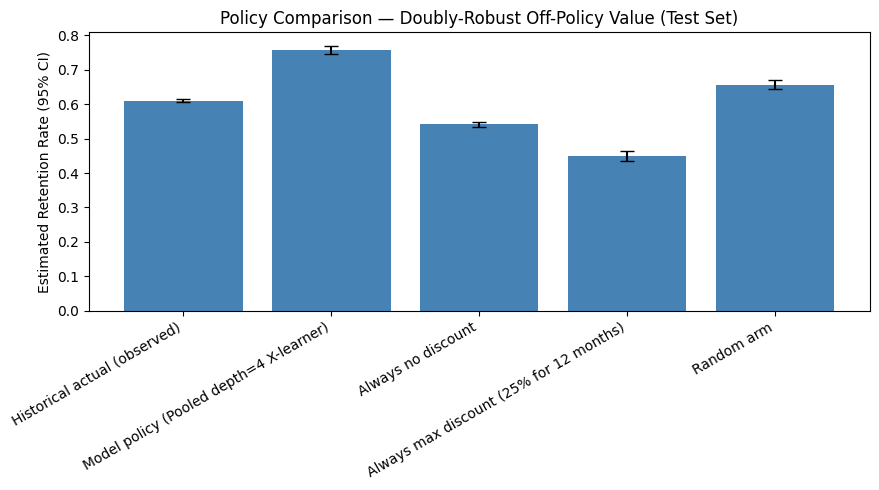

In [12]:
def dr_policy_value(choice_arr, X_eval, T_actual, Y_actual, mu_models, prop_model):
    n = len(choice_arr)
    prop_all = prop_model.predict_proba(X_eval)
    class_index = {c: i for i, c in enumerate(prop_model.classes_)}
    psi = np.empty(n)
    for d in np.unique(choice_arr):
        mask = choice_arr == d
        g = np.clip(prop_all[mask, class_index[d]], 0.05, 0.95)
        mu_d_x = mu_models[d].predict(X_eval[mask])
        indicator = (T_actual[mask] == d).astype(float)
        psi[mask] = mu_d_x + indicator / g * (Y_actual[mask] - mu_d_x)
    return psi


kind_x, models_x = candidates[winner_label.replace('T-learner', 'X-learner')]
mu_for_dr = models_x['mu']

d_test_actual = test_df['arm'].to_numpy()
y_test_actual = test_df['Retained'].to_numpy()

# Keyed by ARM label throughout. The control column has to be CONTROL ('0_0') rather
# than 0, or idxmax returns an integer for any row where no discount beats doing
# nothing, and the doubly-robust estimator then looks that up in models keyed by string.
pred_matrix = {CONTROL: np.zeros(len(test_df))}
for d in TREATMENT_TIERS:
    pred_matrix[d] = predict_winner(X_test, d)
pred_df = pd.DataFrame(pred_matrix, index=test_df.index)
model_choice = pred_df.idxmax(axis=1).to_numpy()

# "Always max" is now the largest discount for the longest time - the policy the
# anchoring effect in the data-generating process punishes hardest, and the most
# useful baseline to beat.
MAX_ARM = f'{max(DISCOUNT_PCTS)}_{max(DISCOUNT_MONTHS)}'

rng = np.random.default_rng(SEED)
policies = {
    f'Model policy ({winner_label})': model_choice,
    'Always no discount': np.full(len(test_df), CONTROL, dtype=object),
    f'Always max discount ({max(DISCOUNT_PCTS)}% for {max(DISCOUNT_MONTHS)} months)':
        np.full(len(test_df), MAX_ARM, dtype=object),
    'Random arm': rng.choice(DISCOUNT_TIERS, size=len(test_df)),
}

results_rows = []
hist_mean = y_test_actual.mean()
hist_se = y_test_actual.std(ddof=1) / np.sqrt(len(y_test_actual))
results_rows.append({'Policy': 'Historical actual (observed)', 'Value': round(hist_mean, 4),
                      'CI_low': round(hist_mean - 1.96*hist_se, 4), 'CI_high': round(hist_mean + 1.96*hist_se, 4),
                      'Paired diff vs historical': 0.0, 'Diff_CI_low': 0.0, 'Diff_CI_high': 0.0})

for name, choice in policies.items():
    psi = dr_policy_value(choice, X_test, d_test_actual, y_test_actual, mu_for_dr, multi_propensity)
    val = psi.mean()
    se = psi.std(ddof=1) / np.sqrt(len(psi))
    delta = psi - y_test_actual
    d_mean, d_se = delta.mean(), delta.std(ddof=1) / np.sqrt(len(delta))
    results_rows.append({'Policy': name, 'Value': round(val, 4),
                          'CI_low': round(val - 1.96*se, 4), 'CI_high': round(val + 1.96*se, 4),
                          'Paired diff vs historical': round(d_mean, 4),
                          'Diff_CI_low': round(d_mean - 1.96*d_se, 4), 'Diff_CI_high': round(d_mean + 1.96*d_se, 4)})

policy_results = pd.DataFrame(results_rows)
print(policy_results.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.bar(policy_results['Policy'], policy_results['Value'],
        yerr=[policy_results['Value'] - policy_results['CI_low'], policy_results['CI_high'] - policy_results['Value']],
        color='steelblue', capsize=5)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Estimated Retention Rate (95% CI)')
plt.title('Policy Comparison — Doubly-Robust Off-Policy Value (Test Set)')
plt.tight_layout()
plt.show()

**Read the `Paired diff vs historical` column, not just the raw values** — that's
the statistically meaningful comparison, since it's computed per-customer against
the same baseline. The model policy's confidence interval for that difference
excludes zero — a real, statistically significant improvement over what was
actually done. "Always max discount" and "random tier" do not clear that bar;
their confidence intervals include zero, so neither is distinguishable from the
historical policy at this sample size.

**Caveats that matter for how much to trust this number:**
- **Extrapolation risk**: the model policy assigns many customers a tier
  different from what they actually got. The further a policy departs from the
  logged (historical) policy, the more this estimate leans on the outcome model
  `mu` being right in regions with less real data to check it against — a known
  weak point of off-policy evaluation, not something the doubly-robust property
  fully eliminates.
- **Propensity clipping** (`g` bounded to [0.05, 0.95]) trades a little bias for
  a lot less variance; without it, a handful of near-zero propensities would
  blow up individual weights and dominate the estimate.
- **No dollar cost accounting** — this compares retention rate only, not
  discount cost in revenue terms.

## 12. Save Model Artifacts

In [13]:
os.makedirs('models', exist_ok=True)

joblib.dump({'model': winner_models, 'kind': winner_kind, 'preprocessor': preprocessor,
             'feature_columns': X_COLS, 'multi_propensity': multi_propensity,
             'arms': DISCOUNT_TIERS},
            'models/uplift_pooled_t_duration.pkl')

config = {
    'winner': winner_label,
    'control_arm': CONTROL,
    'treatment_arms': TREATMENT_TIERS,
    'treatment_pcts': DISCOUNT_PCTS,
    'treatment_months': DISCOUNT_MONTHS,
    'excluded_features': {
        'MRR': 'one-to-one with Plan_Tier under standardised tier pricing',
        'Days_To_Renewal': 'calendar position, not an account attribute; carried no signal',
    },
    'feature_columns': X_COLS,
    'n_training_rows': int(len(train_df)),
    'validation_mean_qini_auc': {k: round(float(v), 4) for k, v in mean_qini.items()},
    'test_qini_auc_by_arm': {r['arm']: r['Qini_AUC'] for r in test_rows},
    'policy_value_test': {r['Policy']: {'value': r['Value'], 'ci': [r['CI_low'], r['CI_high']]}
                           for r in policy_results.to_dict('records')},
}
with open('models/uplift_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved -> models/uplift_pooled_t_duration.pkl')
print('Saved -> models/uplift_config.json')

Saved -> models/uplift_pooled_t_duration.pkl
Saved -> models/uplift_config.json


In [14]:
# Round-trip check on one arm - tiers are labels like '10_6' now, not integers.
CHECK_ARM = TREATMENT_TIERS[0]
loaded = joblib.load('models/uplift_pooled_t_duration.pkl')
reloaded_pred = x_cate(loaded['model'], X_test, CHECK_ARM) if loaded['kind'] == 'x' else t_cate(loaded['model'], X_test, CHECK_ARM)
original_pred = predict_winner(X_test, CHECK_ARM)
assert np.allclose(reloaded_pred, original_pred), 'Mismatch after reload!'
print('Verification passed — reloaded model predictions match original.')
print('Model ready to use: models/uplift_pooled_t_duration.pkl')

Verification passed — reloaded model predictions match original.
Model ready to use: models/uplift_pooled_t_duration.pkl
